In [1]:
# =============================================================================
# PROJET : ANALYSE & PRÉVISION DES RECETTES FISCALES GENEVOISES
# Notebook : 01_exploration.ipynb
# Auteur   : Frat DAG
# Date     : Avril 2026
# Version  : 2.0 — approche inductive (traduction Python du script R)
# =============================================================================

# Vérification des packages
import sys
print(f"Python : {sys.version}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

print("✓ Tous les packages sont disponibles")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  matplotlib : {plt.matplotlib.__version__}")
print(f"  seaborn    : {sns.__version__}")

Python : 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
✓ Tous les packages sont disponibles
  pandas     : 3.0.2
  numpy      : 2.4.4
  matplotlib : 3.10.8
  seaborn    : 0.13.2


In [2]:
# =============================================================================
# 1. SAISIE DES DONNÉES FISCALES
# =============================================================================
# Source : OCSTAT T18.02.1.15 — Revenus d'impôts de l'État de Genève
# Unité  : millions de CHF, totaux annuels
# Période: 2007–2024 (N=18)
#
# NOTE NOMENCLATURE :
# ben_pm      = impôt sur le bénéfice des personnes morales (OCSTAT)
# enreg_timbre = "Produits de l'enregistrement et timbre" (OCSTAT)
#               agrège droits de mutation, droits de timbre et autres
# pp_total    = proxy IR cohérent 2007-2024 (artefact nomenclature 2012)
# =============================================================================

fiscal = pd.DataFrame({
    'annee': range(2007, 2025),

    # Impôts personnes physiques
    'pp_total': [3699.6, 3831.1, 3726.9, 3569.6, 3700.9,
                 3915, 3724, 3941, 3888, 3779, 4005, 4037,
                 4322, 4562, 4285, 5274, 5006, 5171],

    'ir': [3221.0, 3379.0, 3182.9, 3031.9, 3113.1,
           2521, 2581, 2831, 2647, 2540, 2530, 2622,
           2802, 2992, 2510, 2919, 3046, 2963],

    'fortune': [461.0, 433.0, 524.8, 512.1, 578.5,
                614, 602, 696, 694, 710, 894, 810,
                928, 953, 980, 1027, 1033, 1207],

    # Impôts personnes morales
    'pm_total': [1246.1, 1302.1, 1183.1, 1080.6, 1240.5,
                 1354, 1448, 1465, 1391, 1474, 1420, 1772,
                 1639, 1350, 1684, 2045, 2600, 2108],

    'ben_pm': [992.6, 1039.8, 945.2, 822.0, 980.9,
               1082, 1151, 1157, 1099, 1165, 1093, 1429,
               1292, 1019, 1416, 1813, 2387, 1925],

    'cap_pm': [252.9, 259.3, 235.9, 253.6, 255.2,
               271, 289, 298, 287, 305, 322, 327,
               342, 311, 263, 215, 204, 183],

    # Autres impôts
    'enreg_timbre': [184.4, 160.4, 217.6, 184.9, 203.2,
                     179, 160, 162, 185, 198, 217, 262,
                     216, 326, 328, 310, 271, 282],

    'successions': [98.5, 107.2, 308.4, 194.6, 98.6,
                    105, 132, 261, 147, 207, 152, 157,
                    195, 188, 187, 264, 324, 255],

    # Part cantonale IFD
    'ifd': [387.0, 362.9, 347.5, 370.6, 453.2,
            396, 372, 399, 375, 367, 393, 473,
            482, 566, 723, 813, 1011, 913],

    # Total
    'total': [5970.9, 6157.2, 6213.5, 5818.6, 6121.4,
              6407, 6278, 6577, 6461, 6528, 6641, 7173,
              7363, 7454, 7871, 9269, 9734, 9269]
})

print(f"✓ Données fiscales : {len(fiscal)} observations, {len(fiscal.columns)} variables")
print(f"  Période : {fiscal['annee'].min()}–{fiscal['annee'].max()}")
print(f"\nAperçu :")
fiscal.head()

✓ Données fiscales : 18 observations, 11 variables
  Période : 2007–2024

Aperçu :


,annee,pp_total,ir,fortune,pm_total,ben_pm,cap_pm,enreg_timbre,successions,ifd,total
0,2007,3699.6,3221.0,461.0,1246.1,992.6,252.9,184.4,98.5,387.0,5970.9
1,2008,3831.1,3379.0,433.0,1302.1,1039.8,259.3,160.4,107.2,362.9,6157.2
2,2009,3726.9,3182.9,524.8,1183.1,945.2,235.9,217.6,308.4,347.5,6213.5
3,2010,3569.6,3031.9,512.1,1080.6,822.0,253.6,184.9,194.6,370.6,5818.6
4,2011,3700.9,3113.1,578.5,1240.5,980.9,255.2,203.2,98.6,453.2,6121.4


In [3]:
# =============================================================================
# 2. DONNÉES MACRO
# =============================================================================

# PIB nominal Genève (OFS — Comptes régionaux)
# Période : 2008–2022 (2022 = provisoire)
pib = pd.DataFrame({
    'annee': range(2008, 2023),
    'pib_ge': [47597, 46480, 48388, 48536, 49397, 50197,
               50311, 50042, 50365, 51443, 53900, 54591,
               52016, 56229, 61231]
})

# SARON mensuel → moyenne annuelle (BNS)
saron_mensuel = pd.DataFrame({
    'date': pd.date_range(start='2000-01', periods=300, freq='MS'),
    'saron': [
        2.28,1.342026,2.361749,2.547827,3.047974,3.054887,
        2.778948,3.125945,2.991287,2.967391,2.955805,3.490226,
        3.308556,3.282052,3.250111,3.085493,3.275508,3.283814,
        3.226346,3.123531,2.027698,2.118133,1.960142,1.469348,
        1.203506,1.571053,1.202675,1.418686,0.974746,0.937309,
        0.703175,0.603556,0.50856,0.517184,0.506908,0.362647,
        0.486557,0.562408,0.177559,0.094747,0.13474,0.14823,
        0.111008,0.053337,0.145845,0.113241,0.117566,0.126631,
        0.098549,0.100093,0.110365,0.108065,0.112946,0.360676,
        0.1953,0.173508,0.53447,0.63083,0.503354,0.497394,
        0.654176,0.67587,0.809343,0.646173,0.665846,0.631008,
        0.678098,0.677405,0.674366,0.673334,0.68404,0.609864,
        0.828563,0.895374,1.05294,1.187275,1.11309,1.242492,
        1.345125,1.370228,1.682963,1.627171,1.768215,1.897995,
        1.905279,1.835111,1.979335,2.066636,2.165807,2.418879,
        2.490651,2.3134,2.209981,2.118889,2.115592,1.873853,
        2.241335,2.240998,1.894609,1.850478,1.796851,1.860357,
        1.955679,1.933609,1.666335,0.522862,0.03909,0.019608,
        0.080879,0.035864,0.031394,0.03359,0.034996,0.020048,
        0.016977,0.018446,0.024256,0.045043,0.043573,0.031984,
        0.027068,0.037635,0.052509,0.027666,0.016089,0.059386,
        0.079548,0.318768,0.093595,0.058606,0.15866,0.050282,
        0.10152,0.078858,0.083753,0.030437,0.02816,0.07111,
        0.05025,-0.009758,0.008339,0.002873,0.02014,0.018136,
        -0.012948,-0.001064,0.007232,-0.017135,0.016374,0.027838,
        -0.057817,-0.023866,0.022813,-0.027541,0.04,0.032766,
        -0.028182,-0.035067,-0.017292,-0.008163,-0.024285,0.004224,
        -0.005746,0.010574,-0.001193,-0.016479,-0.033343,0.089315,
        -0.015391,-0.02602,-0.000316,-0.038873,-0.022355,-0.036625,
        -0.034751,0.006218,0.01231,-0.034484,-0.015032,0.003368,
        -0.678498,-0.7561,-0.730568,-0.722648,-0.726401,-0.727129,
        -0.738677,-0.724588,-0.719895,-0.724732,-0.72187,-0.721086,
        -0.723007,-0.733788,-0.737954,-0.726368,-0.729792,-0.765593,
        -0.745432,-0.731087,-0.744965,-0.729412,-0.728146,-0.731921,
        -0.732656,-0.72986,-0.737014,-0.738899,-0.734836,-0.734155,
        -0.732636,-0.732305,-0.742996,-0.737404,-0.736376,-0.746149,
        -0.740278,-0.759249,-0.73834,-0.729806,-0.728226,-0.730086,
        -0.730823,-0.731997,-0.785767,-0.73731,-0.732697,-0.730971,
        -0.731819,-0.738785,-0.737656,-0.73173,-0.73687,-0.74023,
        -0.74512,-0.74726,-0.74627,-0.73297,-0.7065,-0.65925,
        -0.70191,-0.70741,-0.66619,-0.65946,-0.65962,-0.66239,
        -0.7037,-0.70568,-0.71371,-0.71804,-0.72109,-0.726264,
        -0.725018,-0.725267,-0.72334,-0.725071,-0.725578,-0.722566,
        -0.721564,-0.72305,-0.672877,-0.693678,-0.680889,-0.68483,
        -0.696923,-0.698075,-0.701726,-0.701592,-0.692302,-0.195447,
        -0.18865,-0.200623,0.43653,0.470718,0.459251,0.942118,
        0.946142,0.937929,1.418617,1.419656,1.441883,1.706544,
        1.702332,1.705343,1.714893,1.704967,1.701526,1.695237,
        1.698236,1.697838,1.464207,1.444518,1.450122,1.215794,
        1.21096,1.217226,0.957401,0.949059,0.942743,0.451195
    ]
})

# IPC mensuel → moyenne annuelle
ipc_mensuel = pd.DataFrame({
    'date': pd.date_range(start='2000-01', periods=300, freq='MS'),
    'ipc': [
        1.6,1.6,1.5,1.4,1.6,1.8,1.9,1.1,1.4,1.3,1.9,1.5,
        1.3,0.8,1,1.2,1.8,1.6,1.4,1.1,0.7,0.6,0.3,0.3,
        0.5,0.7,0.5,1.1,0.6,0.3,-0.1,0.5,0.5,1.2,0.9,0.9,
        0.8,0.9,1.3,0.7,0.4,0.5,0.3,0.5,0.5,0.5,0.5,0.6,
        0.2,0.1,-0.1,0.5,0.9,1.1,0.9,1,0.9,1.3,1.5,1.3,
        1.2,1.4,1.4,1.4,1.1,0.7,1.2,1,1.4,1.3,1,1,
        1.3,1.4,1,1.1,1.4,1.6,1.4,1.5,0.8,0.3,0.5,0.6,
        0.1,0,0.2,0.5,0.5,0.6,0.7,0.4,0.7,1.3,1.8,2,
        2.4,2.4,2.6,2.3,2.9,2.9,3.1,2.9,2.9,2.6,1.5,0.7,
        0.1,0.2,-0.4,-0.3,-1,-1,-1.2,-0.8,-0.9,-0.8,0,0.3,
        1,0.9,1.4,1.4,1.1,0.5,0.4,0.3,0.3,0.2,0.2,0.5,
        0.3,0.5,1,0.3,0.4,0.6,0.5,0.2,0.5,-0.1,-0.5,-0.7,
        -0.8,-0.9,-1,-1,-1,-1.1,-0.7,-0.5,-0.4,-0.2,-0.4,-0.4,
        -0.3,-0.3,-0.6,-0.6,-0.5,-0.1,0,0,-0.1,-0.3,0.1,0.1,
        0.1,-0.1,0,0,0.2,0,-0,-0.1,-0.1,0,-0.1,-0.3,
        -0.5,-0.8,-0.9,-1.1,-1.2,-1,-1.3,-1.4,-1.4,-1.4,-1.4,-1.3,
        -1.3,-0.8,-0.9,-0.4,-0.4,-0.4,-0.2,-0.1,-0.2,-0.2,-0.3,0,
        0.3,0.6,0.6,0.4,0.5,0.2,0.3,0.5,0.7,0.7,0.8,0.8,
        0.7,0.6,0.8,0.8,1,1.1,1.2,1.2,1,1.1,0.9,0.7,
        0.6,0.6,0.7,0.7,0.6,0.6,0.3,0.3,0.1,-0.3,-0.1,0.2,
        0.2,-0.1,-0.5,-1.1,-1.3,-1.3,-0.9,-0.9,-0.8,-0.6,-0.7,-0.8,
        -0.5,-0.5,-0.2,0.3,0.6,0.6,0.7,0.9,0.9,1.2,1.5,1.5,
        1.6,2.2,2.4,2.5,2.9,3.4,3.4,3.5,3.3,3,3,2.8,
        3.3,3.4,2.9,2.6,2.2,1.7,1.6,1.6,1.7,1.7,1.4,1.7,
        1.3,1.2,1,1.4,1.4,1.3,1.3,1.1,0.8,0.6,0.7,0.6
    ]
})

# Agrégation annuelle — filtrer 2007-2024
saron_a = (saron_mensuel
           .assign(annee=lambda x: x['date'].dt.year)
           .query('2007 <= annee <= 2024')
           .groupby('annee')['saron']
           .mean()
           .reset_index())

ipc_a = (ipc_mensuel
         .assign(annee=lambda x: x['date'].dt.year)
         .query('2007 <= annee <= 2024')
         .groupby('annee')['ipc']
         .mean()
         .reset_index())

# Tableau consolidé
df = (fiscal
      .merge(pib, on='annee', how='left')
      .merge(saron_a, on='annee', how='left')
      .merge(ipc_a, on='annee', how='left'))

# Variables dérivées
df['var_total']   = df['total'].diff()
df['var_total_p'] = df['total'].pct_change() * 100
df['var_ben_pm']  = df['ben_pm'].diff()
df['var_ifd']     = df['ifd'].diff()

# Dummies
df['dummy_rffa']      = (df['annee'] >= 2022).astype(int)
df['dummy_covid']     = (df['annee'] == 2020).astype(int)
df['dummy_succ_2009'] = (df['annee'] == 2009).astype(int)

print(f"✓ Tableau consolidé : {len(df)} observations, {len(df.columns)} variables")
print(f"  Valeurs manquantes par colonne :")
print(df.isnull().sum()[df.isnull().sum() > 0])

✓ Tableau consolidé : 18 observations, 21 variables
  Valeurs manquantes par colonne :
pib_ge         3
var_total      1
var_total_p    1
var_ben_pm     1
var_ifd        1
dtype: int64


In [4]:
# =============================================================================
# 3. STATISTIQUES DESCRIPTIVES
# =============================================================================

# TCAM (Taux de Croissance Annuel Moyen)
def tcam(serie):
    n = len(serie) - 1
    return (serie.iloc[-1] / serie.iloc[0]) ** (1/n) - 1

print("=== TCAM 2007–2024 ===")
print(f"  Total recettes : {tcam(df['total'])*100:.2f}%")
print(f"  IR             : {tcam(df['ir'])*100:.2f}%")
print(f"  Bénéfice PM    : {tcam(df['ben_pm'])*100:.2f}%")
print(f"  IFD            : {tcam(df['ifd'])*100:.2f}%")

# Coefficient de variation
def cv(serie):
    return serie.std() / serie.mean() * 100

print("\n=== COEFFICIENT DE VARIATION (%) ===")
for col, label in [('total','Total recettes'), ('ir','IR'),
                   ('ben_pm','Bénéfice PM'), ('fortune','Fortune'),
                   ('enreg_timbre','Enreg. et timbre'),
                   ('successions','Successions'), ('ifd','IFD')]:
    print(f"  {label:20s} : {cv(df[col]):.1f}%")

# Variations annuelles
print("\n=== VARIATIONS ANNUELLES DU TOTAL (M CHF) ===")
print(df[['annee','total','var_total','var_total_p']]
      .round(1).to_string(index=False))

# Anomalies
print("\n=== ANOMALIES ET POINTS ATYPIQUES ===")
succ_2009 = df.loc[df['annee']==2009, 'successions'].values[0]
print(f"Successions 2009 : {succ_2009}M — médiane : {df['successions'].median():.0f}M")
print(f"Variation 2022   : {df.loc[df['annee']==2022,'var_total_p'].values[0]:.1f}% — plus forte hausse")
print(f"Variation 2010   : {df.loc[df['annee']==2010,'var_total_p'].values[0]:.1f}% — plus forte baisse")
print(f"IFD 2023         : {df.loc[df['annee']==2023,'ifd'].values[0]}M — médiane : {df['ifd'].median():.0f}M")
print(f"Bénéfice PM 2023 : {df.loc[df['annee']==2023,'ben_pm'].values[0]}M — médiane : {df['ben_pm'].median():.0f}M")

=== TCAM 2007–2024 ===
  Total recettes : 2.62%
  IR             : -0.49%
  Bénéfice PM    : 3.97%
  IFD            : 5.18%

=== COEFFICIENT DE VARIATION (%) ===
  Total recettes       : 17.2%
  IR                   : 9.7%
  Bénéfice PM          : 31.7%
  Fortune              : 30.0%
  Enreg. et timbre     : 25.4%
  Successions          : 37.8%
  IFD                  : 40.8%

=== VARIATIONS ANNUELLES DU TOTAL (M CHF) ===
 annee  total  var_total  var_total_p
  2007 5970.9        NaN          NaN
  2008 6157.2      186.3          3.1
  2009 6213.5       56.3          0.9
  2010 5818.6     -394.9         -6.4
  2011 6121.4      302.8          5.2
  2012 6407.0      285.6          4.7
  2013 6278.0     -129.0         -2.0
  2014 6577.0      299.0          4.8
  2015 6461.0     -116.0         -1.8
  2016 6528.0       67.0          1.0
  2017 6641.0      113.0          1.7
  2018 7173.0      532.0          8.0
  2019 7363.0      190.0          2.6
  2020 7454.0       91.0          1.2
  202

In [6]:
import os

# Créer le dossier figures s'il n'existe pas
os.makedirs('../figures', exist_ok=True)
print("✓ Dossier figures créé")

✓ Dossier figures créé


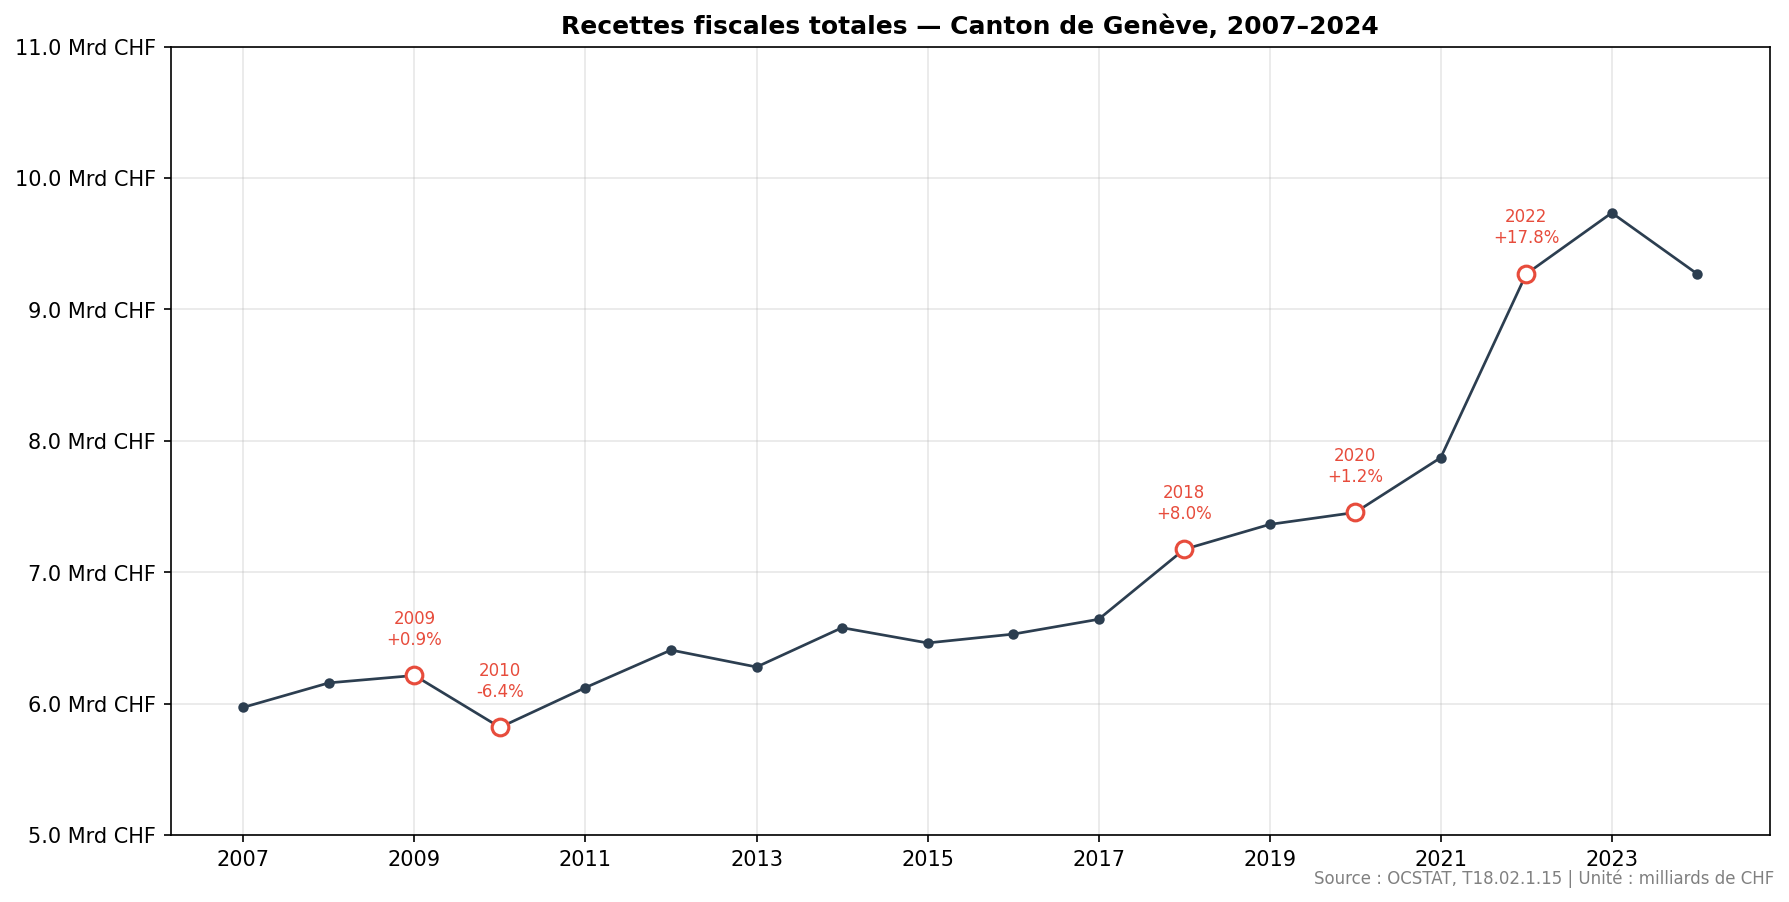

✓ Graphique 1 sauvegardé


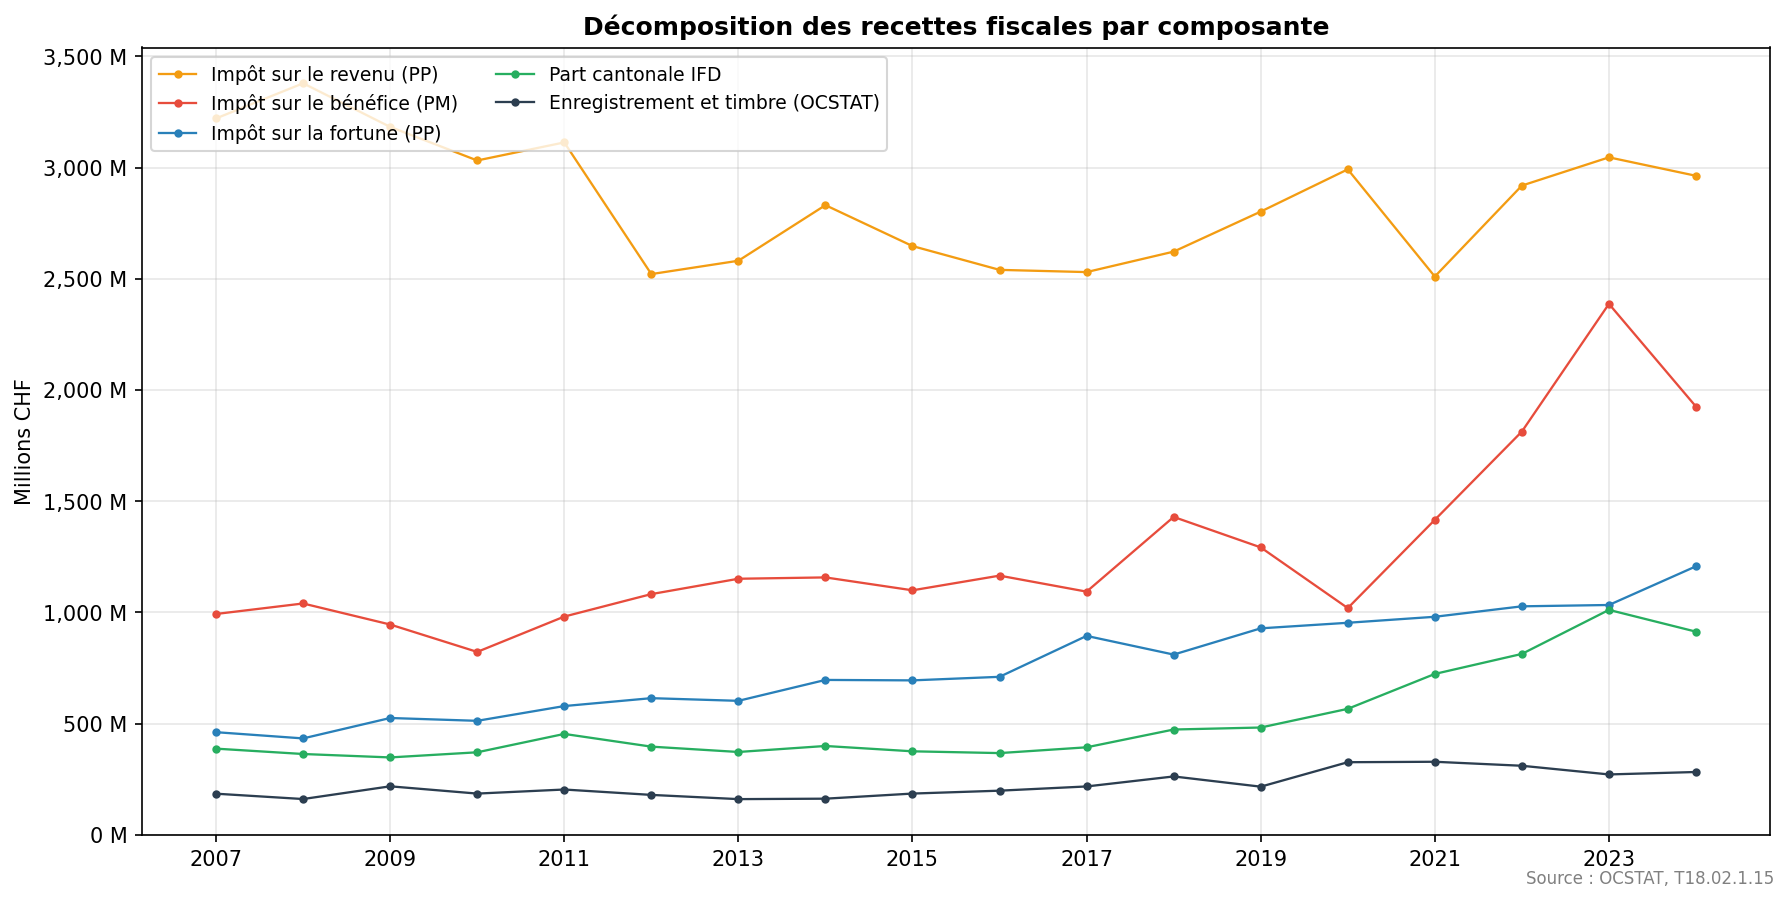

✓ Graphique 2 sauvegardé


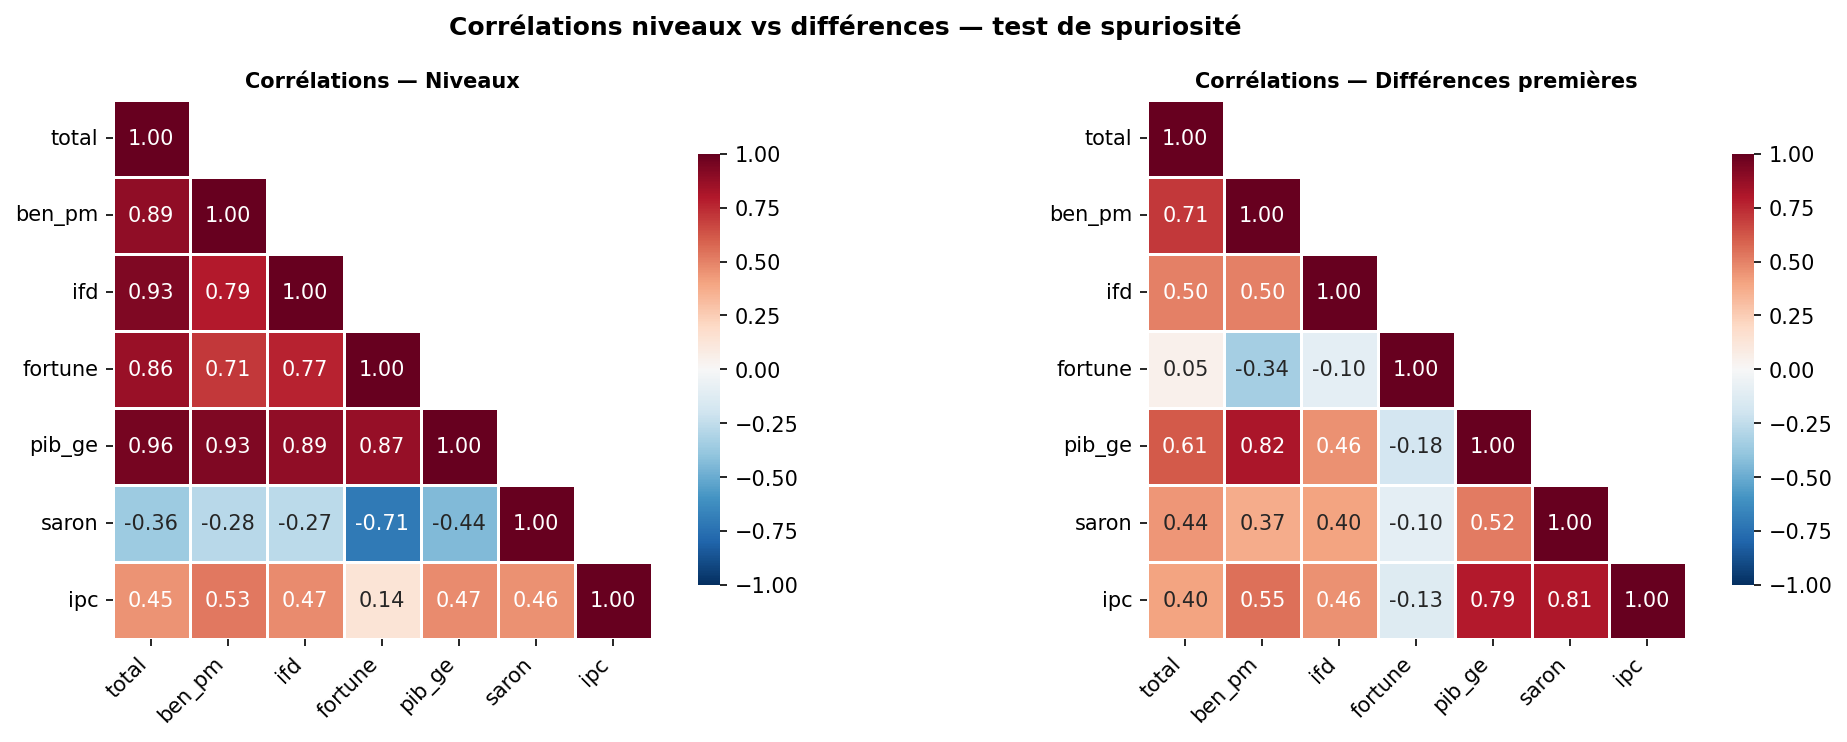

✓ Graphique 3 sauvegardé


In [12]:
# =============================================================================
# 4. GRAPHIQUES
# =============================================================================

COULEURS = ['#2C3E50', '#E74C3C', '#2980B9', '#27AE60', '#F39C12']
plt.rcParams['figure.dpi'] = 150

# --- Graphique 1 : Évolution du total ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['annee'], df['total'], color=COULEURS[0],
        linewidth=1.3, marker='o', markersize=4)

# Annotations années atypiques
ruptures = df[df['var_total_p'].abs() > 8].dropna()
for _, row in ruptures.iterrows():
    ax.plot(row['annee'], row['total'], 'o',
            color=COULEURS[1], markersize=8,
            markerfacecolor='white', markeredgewidth=1.5)
    signe = '+' if row['var_total_p'] > 0 else ''
    ax.annotate(f"{int(row['annee'])}\n{signe}{row['var_total_p']:.1f}%",
                xy=(row['annee'], row['total']),
                xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=8, color=COULEURS[1])

# Années COVID et 2010 aussi
for annee in [2009, 2010, 2020]:
    row = df[df['annee'] == annee].iloc[0]
    if abs(row['var_total_p']) <= 8:
        ax.plot(row['annee'], row['total'], 'o',
                color=COULEURS[1], markersize=8,
                markerfacecolor='white', markeredgewidth=1.5)
        signe = '+' if row['var_total_p'] > 0 else ''
        ax.annotate(f"{int(row['annee'])}\n{signe}{row['var_total_p']:.1f}%",
                    xy=(row['annee'], row['total']),
                    xytext=(0, 15), textcoords='offset points',
                    ha='center', fontsize=8, color=COULEURS[1])

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.1f} Mrd CHF"))
ax.set_ylim(5000, 11000)
ax.set_xticks(range(2007, 2025, 2))
ax.set_title("Recettes fiscales totales — Canton de Genève, 2007–2024",
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01, "Source : OCSTAT, T18.02.1.15 | Unité : milliards de CHF",
         ha='right', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../figures/01_total_evolution_py.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 1 sauvegardé")

# --- Graphique 2 : Décomposition par composante ---
fig, ax = plt.subplots(figsize=(12, 6))

composantes = {
    'ir'          : ('Impôt sur le revenu (PP)', COULEURS[4]),
    'ben_pm'      : ('Impôt sur le bénéfice (PM)', COULEURS[1]),
    'fortune'     : ('Impôt sur la fortune (PP)', COULEURS[2]),
    'ifd'         : ('Part cantonale IFD', COULEURS[3]),
    'enreg_timbre': ('Enregistrement et timbre (OCSTAT)', COULEURS[0])
}

for col, (label, couleur) in composantes.items():
    ax.plot(df['annee'], df[col], label=label,
            color=couleur, linewidth=1.1, marker='o', markersize=3)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f} M"))
ax.set_xticks(range(2007, 2025, 2))
ax.set_title("Décomposition des recettes fiscales par composante",
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Millions CHF')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01, "Source : OCSTAT, T18.02.1.15",
         ha='right', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../figures/01_decomposition_py.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 2 sauvegardé")

# --- Graphique 3 : Matrice de corrélation en différences ---
df_diff = df.dropna(subset=['pib_ge']).copy()
cols_corr = ['total','ben_pm','ifd','fortune','pib_ge','saron','ipc']
corr_niveaux = df_diff[cols_corr].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (corr_mat, titre) in zip(axes, [
    (corr_niveaux, "Corrélations — Niveaux"),
    (df_diff[cols_corr].diff().dropna().corr().round(2),
     "Corrélations — Différences premières")
]):
    mask = np.zeros_like(corr_mat, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True
    sns.heatmap(corr_mat, ax=ax, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                mask=mask, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle("Corrélations niveaux vs différences — test de spuriosité",
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/01_correlations_py.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique 3 sauvegardé")

In [11]:
os.makedirs('../data', exist_ok=True)
print("✓ Dossier data créé")

# =============================================================================
# 5. DÉCISION FINALE — QUESTIONS POUR LE NOTEBOOK 02
# =============================================================================

print("=" * 60)
print("QUESTIONS POSÉES PAR LES DONNÉES — NOTEBOOK 02")
print("=" * 60)

questions = {
    "Q7 — RUPTURE NOMENCLATURE IR": 
        "L'IR recule nominalement (-0.49%/an). Artefact 2012 ?\n"
        "→ Vérifier IR seul vs IR+source avant tout test",
    
    "Q1 — STATIONNARITÉ":
        "Tendance haussière visible + ruptures 2010 et 2022.\n"
        "→ Tests ADF, PP, KPSS sur chaque série principale",
    
    "Q2 — RUPTURES STRUCTURELLES":
        "2010, 2020, 2022 visuellement atypiques.\n"
        "→ Test de Chow sur ces points",
    
    "Q3 — OUTLIER SUCCESSIONS 2009":
        f"308M vs médiane 188M (1.7σ).\n"
        "→ Dummy variable ou exclusion",
    
    "Q4 — COINTÉGRATION":
        "Si séries I(1), sont-elles cointégrées ?\n"
        "→ Test de Johansen → VAR diff vs VECM",
    
    "Q5 — CORRÉLATIONS MACRO":
        "Fortune : 0.86 en niveaux → 0.05 en différences → spurieuse.\n"
        "→ Confirmer après tests de stationnarité",
    
    "Q6 — DUMMY RFFA":
        "Hausse 2022 partiellement attribuable à la RFFA.\n"
        "→ dummy_rffa = 1 si annee >= 2022, testée formellement"
}

for titre, texte in questions.items():
    print(f"\n{titre}")
    print(f"    {texte.replace(chr(10), chr(10)+'    ')}")

print("\n→ Le notebook 02 répondra à ces questions dans cet ordre.")
print("→ Les réponses détermineront les modèles du notebook 03.")

# Sauvegarde du dataframe pour les notebooks suivants
df.to_csv('../data/df_fiscal.csv', index=False)
print("\n✓ Données sauvegardées dans ../data/df_fiscal.csv")

✓ Dossier data créé
QUESTIONS POSÉES PAR LES DONNÉES — NOTEBOOK 02

Q7 — RUPTURE NOMENCLATURE IR
    L'IR recule nominalement (-0.49%/an). Artefact 2012 ?
    → Vérifier IR seul vs IR+source avant tout test

Q1 — STATIONNARITÉ
    Tendance haussière visible + ruptures 2010 et 2022.
    → Tests ADF, PP, KPSS sur chaque série principale

Q2 — RUPTURES STRUCTURELLES
    2010, 2020, 2022 visuellement atypiques.
    → Test de Chow sur ces points

Q3 — OUTLIER SUCCESSIONS 2009
    308M vs médiane 188M (1.7σ).
    → Dummy variable ou exclusion

Q4 — COINTÉGRATION
    Si séries I(1), sont-elles cointégrées ?
    → Test de Johansen → VAR diff vs VECM

Q5 — CORRÉLATIONS MACRO
    Fortune : 0.86 en niveaux → 0.05 en différences → spurieuse.
    → Confirmer après tests de stationnarité

Q6 — DUMMY RFFA
    Hausse 2022 partiellement attribuable à la RFFA.
    → dummy_rffa = 1 si annee >= 2022, testée formellement

→ Le notebook 02 répondra à ces questions dans cet ordre.
→ Les réponses détermineron